In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

### 1. Data Collection/Preparation

Now that the dataset is downloaded, let's load it into a pandas DataFrame.

In [ ]:
import pandas as pd
import os

# The 'path' variable from the previous cell points to the dataset directory.
# Let's find the CSV file within that directory.

# List contents of the downloaded directory to find the CSV file
dataset_files = os.listdir(path)
csv_file = [f for f in dataset_files if f.endswith('.csv')][0]

# Construct the full path to the CSV file
full_csv_path = os.path.join(path, csv_file)

# Load the dataset into a pandas DataFrame
imdb_df = pd.read_csv(full_csv_path)

# Display the first 5 rows and information about the DataFrame
display(imdb_df.head())
imdb_df.info()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### 2. Data Preprocessing

This step involves cleaning the text data. For this dataset, we'll focus on removing HTML tags (like `<br />`), converting text to lowercase, removing punctuation, and removing common English stop words. We'll use `nltk` for tokenization and stop word removal.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK data (run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    # Download 'punkt_tab' which is implicitly required by word_tokenize for some languages/models
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Remove HTML tags (e.g., <br />)
    text = re.sub(r'<.*?>', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    words = word_tokenize(text)
    # Remove stop words and non-alphabetic tokens
    words = [word for word in words if word.isalpha() and word not in stop_words]
    return ' '.join(words)

print("Applying text preprocessing to the 'review' column...")
imdb_df['processed_review'] = imdb_df['review'].apply(preprocess_text)

display(imdb_df[['review', 'processed_review', 'sentiment']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying text preprocessing to the 'review' column...


,review,processed_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


### 3. Feature Extraction

Now, we will convert our preprocessed text data (`processed_review`) into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF reflects how important a word is to a document in a collection or corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer. You can adjust max_features as needed.
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for managing computational complexity and memory

# Fit and transform the processed text data
X = tfidf_vectorizer.fit_transform(imdb_df['processed_review'])

# Map sentiment labels to numerical values (e.g., negative: 0, neutral: 1, positive: 2)
# First, check unique sentiments to define a mapping if necessary. In this dataset, we expect 'positive' and 'negative'.
print("Unique sentiment labels:", imdb_df['sentiment'].unique())

# For binary classification (positive/negative), we can map them to 1s and 0s
y = imdb_df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

print("Shape of TF-IDF features (X):", X.shape)
print("Shape of target variable (y):", y.shape)
print("First 10 feature names:", tfidf_vectorizer.get_feature_names_out()[:10])

Unique sentiment labels: ['positive' 'negative']
Shape of TF-IDF features (X): (50000, 5000)
Shape of target variable (y): (50000,)
First 10 feature names: ['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely']


### 4. Model Building & Training

Now that we have our features (X) and target variable (y), we'll split the data into training and testing sets. Then, we'll initialize and train a Logistic Regression model, a common and effective baseline for text classification.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split data into training and testing sets
# We'll use a test size of 20% and stratify by 'y' to maintain the proportion of sentiment classes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train the Logistic Regression model
# Increasing max_iter for convergence with a larger dataset
model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and L1/L2 regularization
model.fit(X_train, y_train)

print("Model trained successfully!")

Shape of X_train: (40000, 5000)
Shape of X_test: (10000, 5000)
Shape of y_train: (40000,)
Shape of y_test: (10000,)
Model trained successfully!


### 5. Model Evaluation

Now we will evaluate the trained model's performance on the test dataset using various metrics like accuracy, precision, recall, and F1-score. We'll also generate a classification report for a more detailed view.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # 'weighted' handles class imbalance
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8875
Precision: 0.8876
Recall: 0.8875
F1-Score: 0.8875

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Confusion Matrix

To further understand the model's predictions, let's visualize the confusion matrix. This will show us where the model is making correct and incorrect classifications.

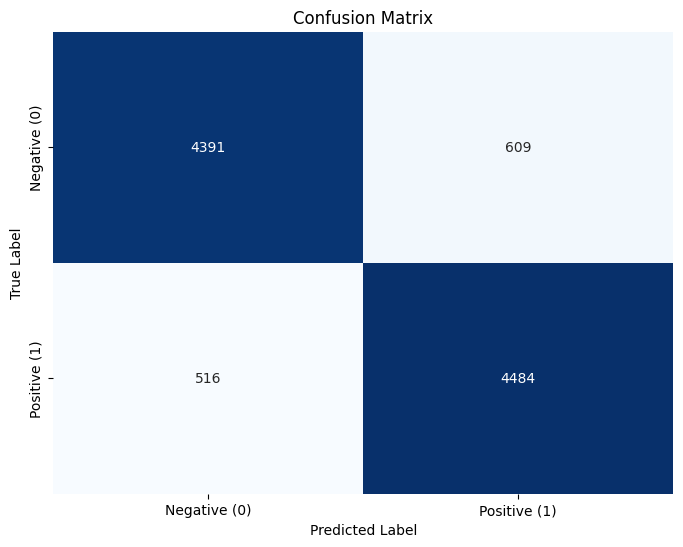

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##Testing the Model on Custom Reviews

In [ ]:
sample_reviews = [
    "This movie was absolutely fantastic. I loved every scene.",
    "The movie was boring and a complete waste of time.",
    "The acting was decent but the story was too long."
]

# Preprocess the sample reviews using the same function used for training data
processed_sample_reviews = [preprocess_text(review) for review in sample_reviews]

# Transform the processed sample reviews using the fitted tfidf_vectorizer
sample_vectors = tfidf_vectorizer.transform(processed_sample_reviews)
predictions = model.predict(sample_vectors)

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: This movie was absolutely fantastic. I loved every scene.
Predicted Sentiment: Positive

Review: The movie was boring and a complete waste of time.
Predicted Sentiment: Negative

Review: The acting was decent but the story was too long.
Predicted Sentiment: Negative



### 6. Hyperparameter Tuning

Hyperparameter tuning is crucial for optimizing model performance. We'll use `GridSearchCV` to systematically search for the best combination of hyperparameters for our Logistic Regression model.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga'] # Solvers that support L1 regularization
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Initialize GridSearchCV
# We use 'f1_weighted' as scoring metric to account for potential class imbalance (though not significant here)
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid,
                           cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

print("Starting GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

# Display the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1-Weighted Score: {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearchCV completed.
Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best F1-Weighted Score: 0.8834


### 7. Evaluate Model with Best Hyperparameters

Now, let's use the model with the best hyperparameters found by `GridSearchCV` to make predictions on the test set and evaluate its performance.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy with tuned model: {accuracy_tuned:.4f}")

print("\nClassification Report with Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

Accuracy with tuned model: 0.8875

Classification Report with Tuned Model:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
import joblib

joblib.dump(best_model, "sentiment_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")

In [ ]:
import joblib

# Load the saved model
loaded_model = joblib.load("sentiment_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [ ]:
review = "This movie was fantastic. I loved every moment."

processed = preprocess_text(review)

vector = loaded_vectorizer.transform([processed])

prediction = loaded_model.predict(vector)

if prediction[0] == 1:
    print("😊 Positive")
else:
    print("😞 Negative")

😊 Positive


In [ ]:
review = "I love this movie that I don't want to see it again"

print(preprocess_text(review))

NameError: name 'preprocess_text' is not defined